# Side Exercise: Get a neural network to simulate a normal distribution

In [1]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

## Generatea dataset of a lot of Gaussians

The objective should be given a whoel bunch of samples, predict which the $\mathcal{N}(\mu, \sigma^2)$ which this data is drawn from.

> This is still a work in progress and this has some issues now.

In [8]:
N = 10000      # samples per distribution
K = 100        # number of distributions

data = []

for _ in range(K):
  mu = torch.empty(1).uniform_(-5, 5).item()
  sigma = torch.empty(1).uniform_(0.5, 3).item()
  dist = torch.normal(mu, sigma, (N, 1))
  data.append([dist, mu, sigma])

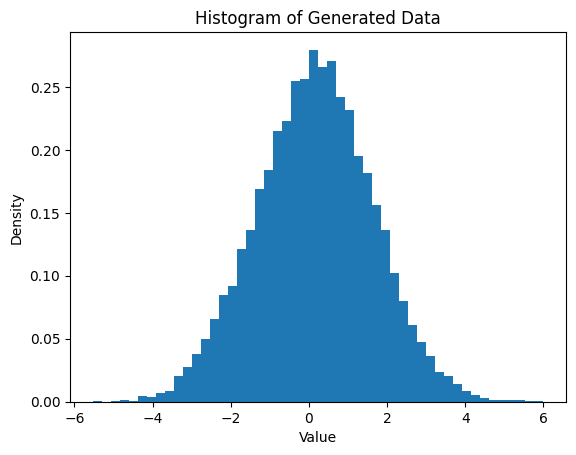

In [10]:
plt.hist(data[0][0].numpy(), bins=50, density=True)
plt.title("Histogram of Generated Data")
plt.xlabel("Value")
plt.ylabel("Density")

plt.show()

In [11]:
class GaussianNet(nn.Module):
  def __init__(self, hidden_dim):
    super().__init__()
    self.hidden_dim = hidden_dim
    self.fc1 = nn.Linear(1, hidden_dim)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_dim, 2)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)

    mu = x[:, 0]
    sigma = x[:, 1]
    return mu, sigma

## Training Objective

The loss should just be the negative log likelihood of the Gaussian

$$\mathcal{L}(\mu, \sigma) = - \frac{1}{N} \sum_{i=1}^N \log \left[\frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2}\right]$$

$$\log \left[\frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2}\right] = \log \left[\frac{1}{\sigma \sqrt{2\pi}}\right] + \log \left[e^{-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2}\right]$$

$$= - \log \left[{\sigma \sqrt{2\pi}}\right] {-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2}$$

$$= - \frac{1}{2}\log \left[{{2\pi} \sigma^2}\right] {-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2}$$

Thus, our final loss is 

$$\mathcal{L}(\mu, \sigma) = \frac{1}{N} \sum_{i=1}^N \frac{1}{2}\log \left[{{2\pi} \sigma^2}\right] + {\frac{1}{2}\left(\frac{x_i - \mu}{\sigma}\right)^2}$$

In [12]:
def gaussian_nll(x, mu, sigma):
  loss = (
    0.5 * torch.log(2 * torch.pi * sigma**2)
      + (x - mu)**2 / (2 * sigma**2)
  )
  return loss.mean()

In [16]:
model = GaussianNet(32)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_history = []

for epoch in range(10):
    for samples, true_mu, true_sigma in data:
        pred_mu, pred_sigma = model(samples)

        loss = gaussian_nll(samples.squeeze(), pred_mu, pred_sigma)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

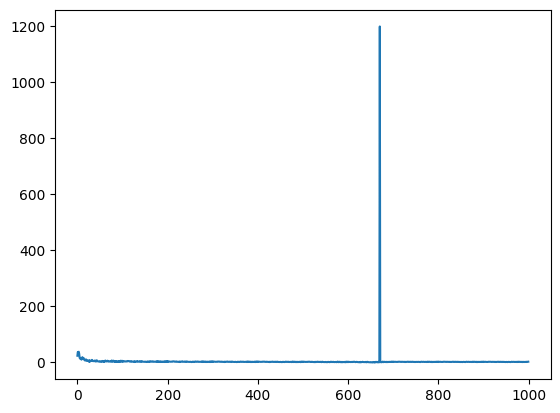

In [17]:
plt.plot(loss_history)

## Ok, so it works for 1 distribution but not a family of distributions

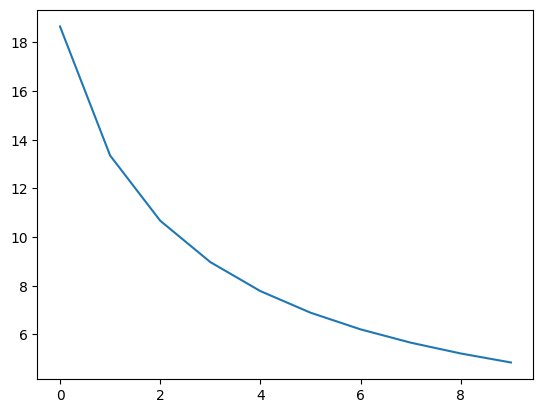

In [18]:
model = GaussianNet(32)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_history = []

for epoch in range(10):
    samples, true_mu, true_sigma = data[0]
    pred_mu, pred_sigma = model(samples)

    loss = gaussian_nll(samples.squeeze(), pred_mu, pred_sigma)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

plt.plot(loss_history)